# Part 1: Predictive Policing

*Check out the readings*

## Exercise 1.1

> Consider the questions

# Part 2: Getting the Data

## Exercise 2.1: Data Exploration

**Columns:** 29 columns that includes date and time of incident, ID and number, other incident details, and type of incident.

Key columns: `Incident Datetime`, `Incident Date`, `Incident Time`, `Incident Year`, `Incident Day of Week`, `Incident Category`, `Incident Subcategory`, `Incident Description`, `Resolution`, `Police District`, `Analysis Neighborhood`, `Latitude`, `Longitude`.

**Rows:** Each row represents a unique reported incident.

**Time range:** 2018–present

**Questions this data can help answer:** Uncover patterns in incidents — e.g. which crime types are most common, how crime rates changed over time (including during COVID), geographic hotspots by district or neighborhood.


## Exercise 2.2: Load and Clean Data


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/Police_Department_Incident_Reports__2018_to_Present_20260203.csv"
)

# Parse dates
df["Incident Date"] = pd.to_datetime(df["Incident Date"])
df["Incident Year"] = df["Incident Year"].astype(int)

df.head()

,Row ID,Incident Datetime,Incident Date,Incident Time,Incident Year,Incident Day of Week,Report Datetime,Incident ID,Incident Number,CAD Number,...,CNN,Police District,Analysis Neighborhood,Supervisor District,Supervisor District 2012,Latitude,Longitude,Point,data_as_of,data_loaded_at
0,150750507041,2025/08/26 11:17:00 PM,2025-08-26,23:17,2025,Tuesday,2025/08/26 11:17:00 PM,1507505,250333102,NaN,...,NaN,Out of SF,NaN,NaN,NaN,NaN,NaN,NaN,2025/08/28 09:38:07 AM,2025/08/29 09:53:03 AM
1,150752104134,2025/08/27 12:37:00 AM,2025-08-27,00:37,2025,Wednesday,2025/08/27 12:37:00 AM,1507521,250479881,252390049.0,...,33557000.0,Park,Lone Mountain/USF,1.0,1.0,37.780415,-122.449013,POINT (-122.449012756 37.780414581),2025/08/28 09:38:07 AM,2025/08/29 09:53:03 AM
2,150762309027,2025/07/17 03:00:00 PM,2025-07-17,15:00,2025,Thursday,2025/08/27 11:55:00 AM,1507623,250480775,252391585.0,...,26469000.0,Park,Lone Mountain/USF,1.0,1.0,37.775177,-122.451355,POINT (-122.45135498 37.775177002),2025/08/28 09:38:07 AM,2025/08/29 09:53:03 AM
3,150740506244,2025/08/23 09:30:00 PM,2025-08-23,21:30,2025,Saturday,2025/08/24 02:53:00 PM,1507405,256091227,NaN,...,25905000.0,Northern,Hayes Valley,6.0,5.0,37.774551,-122.422501,POINT (-122.42250061 37.774551392),2025/08/27 09:38:07 AM,2025/08/28 09:53:00 AM
4,150723571000,2025/08/15 12:00:00 PM,2025-08-15,12:00,2025,Friday,2025/08/24 07:10:00 PM,1507235,256090348,NaN,...,26412000.0,Park,Haight Ashbury,5.0,5.0,37.769661,-122.449646,POINT (-122.449645996 37.76966095),2025/08/27 09:38:07 AM,2025/08/28 09:53:00 AM


In [ ]:
# Keep only complete years:
# Drop the earliest year if the data doesn't start on Jan 1,
# and drop the current (incomplete) year.
import datetime

min_date = df['Incident Date'].min()
max_date = df['Incident Date'].max()
print(f"Raw data range: {min_date.date()} to {max_date.date()}")

# Determine complete years
first_complete_year = min_date.year if (min_date.month == 1 and min_date.day == 1) else min_date.year + 1
last_complete_year  = max_date.year if (max_date.month == 12 and max_date.day == 31) else max_date.year - 1

df_clean = df[df['Incident Year'].between(first_complete_year, last_complete_year)].copy()

# Keep only the columns we need
cols = ['Incident Date', 'Incident Year', 'Incident Day of Week',
        'Incident Category', 'Incident Subcategory', 'Incident Description',
        'Resolution', 'Police District', 'Analysis Neighborhood',
        'Latitude', 'Longitude']
df_clean = df_clean[cols]

print(f"\nComplete years: {first_complete_year}–{last_complete_year}")
print(f"Total incidents: {len(df_clean):,}")
print(f"Date range: {df_clean['Incident Date'].min().date()} to {df_clean['Incident Date'].max().date()}")
print(f"Incident categories: {df_clean['Incident Category'].nunique()}")

Raw data range: 2018-01-01 to 2026-02-01

Complete years: 2018–2025
Total incidents: 997,315
Date range: 2018-01-01 to 2025-12-31
Incident categories: 49


# Part 3: Exploring Crime Categories

## Exercise 3.1


In [15]:
category_counts = df_clean['Incident Category'].value_counts()

print(f"Total unique categories: {len(category_counts)}\n")
print("Top 10 most common:")
print(category_counts.head(10).to_string())
print("\nTop 10 least common:")
print(category_counts.tail(10).to_string())

Total unique categories: 49

Top 10 most common:
Incident Category
Larceny Theft          293262
Other Miscellaneous     68972
Malicious Mischief      68325
Assault                 64549
Burglary                55881
Motor Vehicle Theft     54801
Recovered Vehicle       40242
Non-Criminal            37921
Fraud                   33692
Warrant                 32980

Top 10 least common:
Incident Category
Rape                                            260
Homicide                                        233
Liquor Laws                                     147
Suspicious                                      133
Human Trafficking (A), Commercial Sex Acts      122
Motor Vehicle Theft?                            102
Gambling                                         66
Weapons Offence                                  28
Human Trafficking, Commercial Sex Acts           25
Human Trafficking (B), Involuntary Servitude      3


## Exercise 3.2


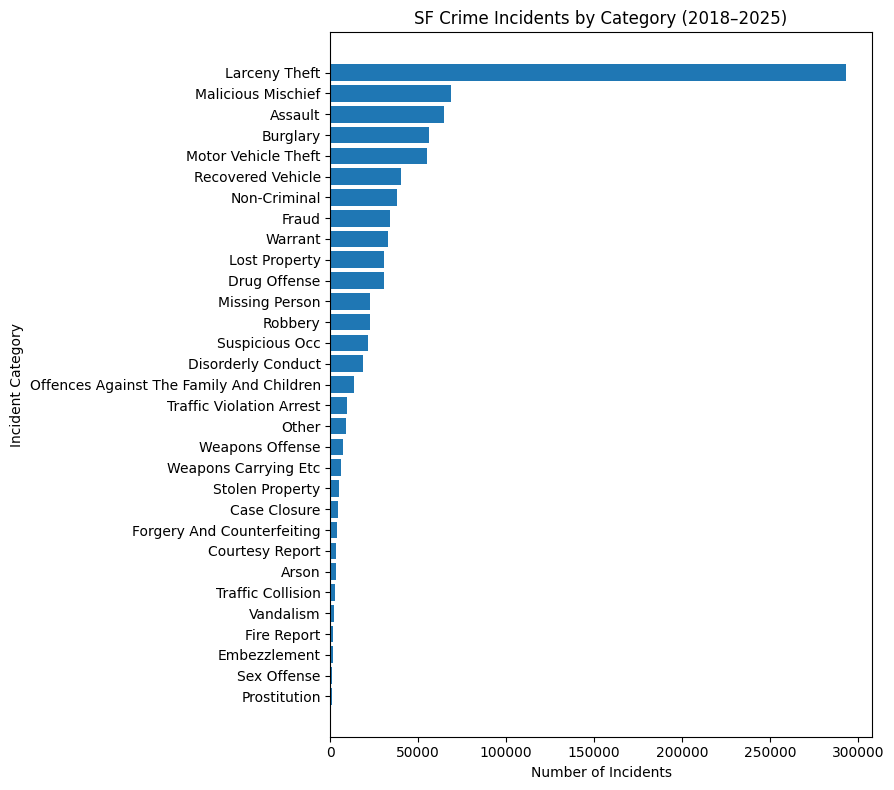

In [17]:
# Remove uninformative catch-all categories and show top categories (>= 1000 incidents)
exclude = {"Other Miscellaneous", "Other Offenses", "Miscellaneous Investigation"}
plot_counts = category_counts[
    (~category_counts.index.isin(exclude)) & (category_counts >= 1000)
].sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(plot_counts.index, plot_counts.values)
ax.set_xlabel("Number of Incidents")
ax.set_ylabel("Incident Category")
ax.set_title(
    f"SF Crime Incidents by Category ({first_complete_year}–{last_complete_year})"
)
plt.tight_layout()
plt.show()

# Part 4: Temporal Patterns

## Exercise 4.1


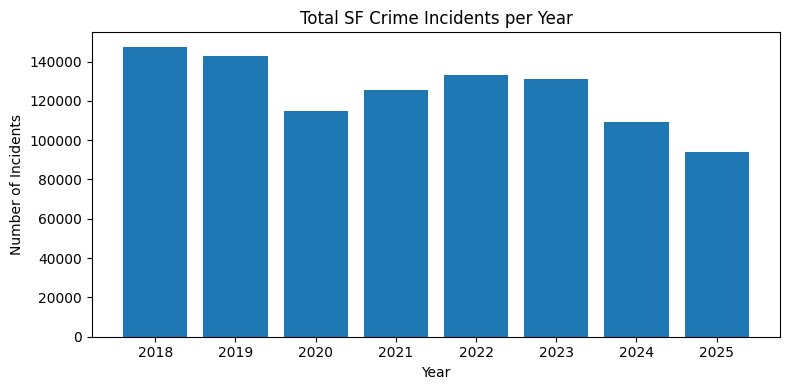

Most incidents: 2018 (147,506)
Fewest incidents: 2025 (93,749)


In [19]:
yearly = df_clean.groupby("Incident Year").size().reset_index(name="Incidents")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(yearly["Incident Year"], yearly["Incidents"])
ax.set_xlabel("Year")
ax.set_ylabel("Number of Incidents")
ax.set_title("Total SF Crime Incidents per Year")
ax.set_xticks(yearly["Incident Year"])
plt.tight_layout()
plt.show()

print(
    f"Most incidents: {yearly.loc[yearly['Incidents'].idxmax(), 'Incident Year']} ({yearly['Incidents'].max():,})"
)
print(
    f"Fewest incidents: {yearly.loc[yearly['Incidents'].idxmin(), 'Incident Year']} ({yearly['Incidents'].min():,})"
)

_Write your observations here — e.g. which years stand out, and what real-world events might explain those patterns?_


## Exercise 4.2


In [21]:
focus_crimes = [
    "Larceny Theft",
    "Assault",
    "Burglary",
    "Motor Vehicle Theft",
    "Fraud",
    "Drug Offense",
    "Missing Person",
    "Robbery",
    "Disorderly Conduct",
    "Weapons Offense",
    "Stolen Property",
    "Arson",
    "Traffic Collision",
    "Vandalism",
    "Sex Offense",
    "Prostitution",
]

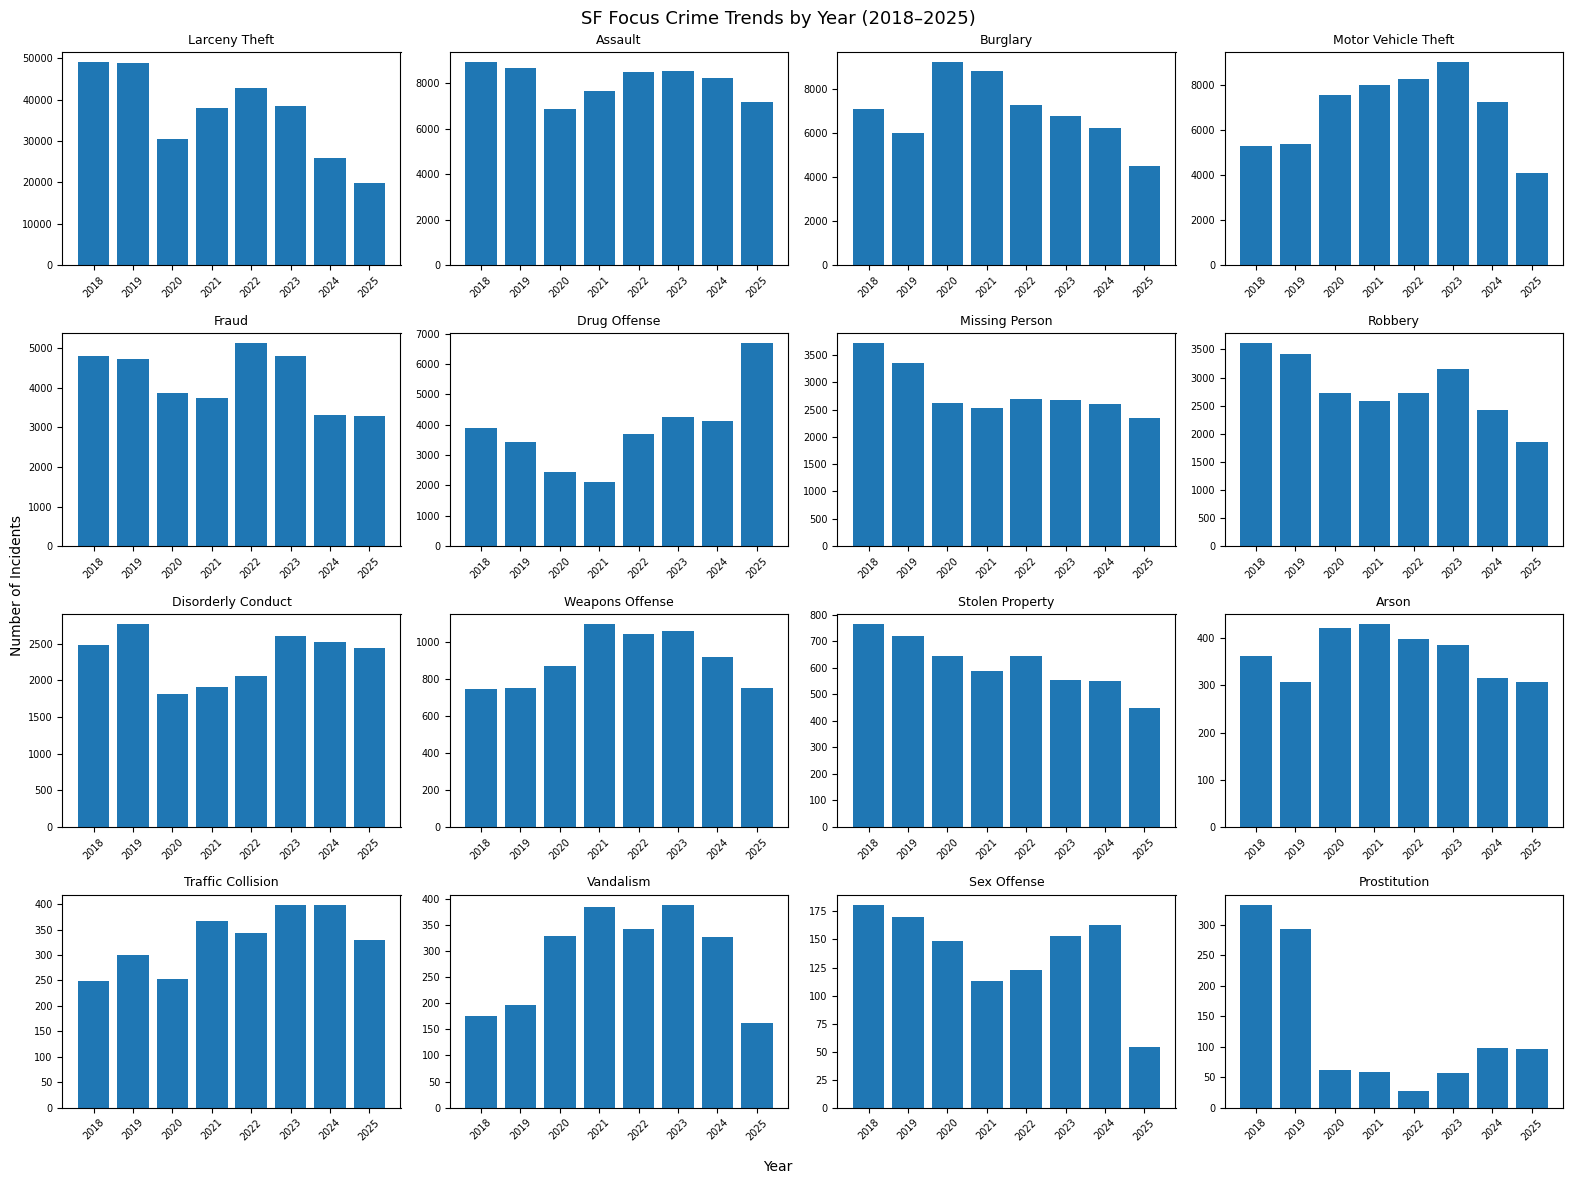

In [22]:
df_focus = df_clean[df_clean["Incident Category"].isin(focus_crimes)]
focus_yearly = (
    df_focus.groupby(["Incident Year", "Incident Category"])
    .size()
    .reset_index(name="Incidents")
)

years = sorted(df_clean["Incident Year"].unique())

fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharey=False)
axes = axes.flatten()

for i, crime in enumerate(focus_crimes):
    ax = axes[i]
    data = focus_yearly[focus_yearly["Incident Category"] == crime]
    ax.bar(data["Incident Year"], data["Incidents"])
    ax.set_title(crime, fontsize=9)
    ax.set_xticks(years)
    ax.tick_params(axis="x", labelrotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle(
    f"SF Focus Crime Trends by Year ({first_complete_year}–{last_complete_year})",
    fontsize=13,
)
fig.supxlabel("Year", fontsize=10)
fig.supylabel("Number of Incidents", fontsize=10)
plt.tight_layout()
plt.show()

## Exercise 4.3

> **Your own thinking required here — the interpretation must be your own. This is where you practice data analysis reasoning.**

*(Write your observations here. Comment on at least three interesting patterns — e.g. which crimes dropped in 2020, which ones recovered, which ones didn't, any surprising trends.)*

**Pattern 1:**

...

**Pattern 2:**

...

**Pattern 3:**

...